# Titanic Data Cleaning and Preprocessing

**Internship Task – Week 1**  
**Dataset:** Kaggle Titanic – Machine Learning from Disaster (train.csv)  

In this notebook, I:
- Load the Titanic dataset.
- Perform initial data exploration.
- Handle missing values, inconsistencies, and outliers.
- Save a cleaned version of the dataset for further analysis.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [5]:
df = pd.read_csv("../data/raw_data.csv")  # Load your dataset
df.head()  # Display the first few rows of the dataset



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
print("Shape: ", df.shape)
print("Column data types: ")
df.info()  # Display information about the dataset, including data types and non-null counts



Shape:  (891, 12)
Column data types: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
missing_count = df.isna().sum()  # Count the number of missing values in each column
missing_pct = (df.isna().mean() * 100).round(2)  # Calculate the percentage of missing values in each column
missing_summary = pd.DataFrame({"missing_count": missing_count, "missing_pct": missing_pct}).sort_values("missing_pct", ascending=False)  # Create a summary DataFrame
missing_summary  # Display the summary of missing values



,missing_count,missing_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Survived,0,0.00
Pclass,0,0.00
Name,0,0.00
Sex,0,0.00
SibSp,0,0.00
Parch,0,0.00


## Data Quality Checks

In this section, I check for duplicate records, inspect categorical columns for inconsistent values, and examine summary statistics for numerical columns.

In [9]:
duplicate_count = df.duplicated().sum()  # Count the number of duplicate rows in the dataset
print("Number of duplicate rows: ", duplicate_count)  # Print the number of duplicate rows  


Number of duplicate rows:  0


In [10]:
categorical_columns = ["Sex", "Embarked", "Pclass"]  # List of categorical columns
for column in categorical_columns:
    print(f"--- {column} ---")
    print(df[column].value_counts(dropna=False))  # Print the value counts for each categorical column
                      

--- Sex ---
Sex
male      577
female    314
Name: count, dtype: int64
--- Embarked ---
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64
--- Pclass ---
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [11]:
df[["Age", "Fare", "SibSp", "Parch"]].describe()  # Display summary statistics for numerical columns

,Age,Fare,SibSp,Parch
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,32.204208,0.523008,0.381594
std,14.526497,49.693429,1.102743,0.806057
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,7.910400,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,38.000000,31.000000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


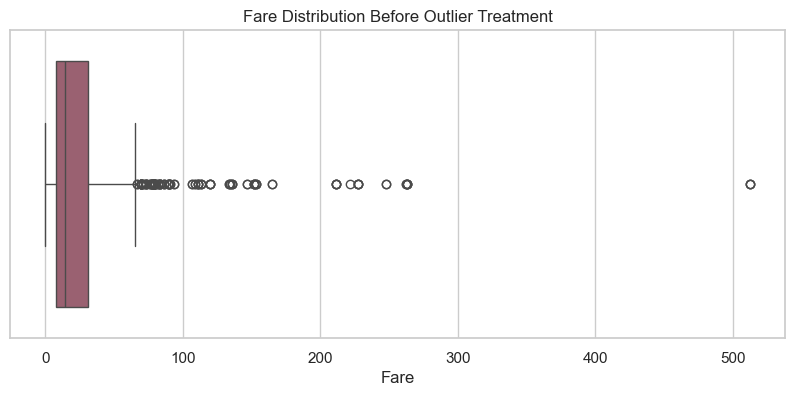

In [17]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["Fare"], color="#A3586D")  # Create a boxplot for the 'Fare' column
plt.title("Fare Distribution Before Outlier Treatment")  # Set the title of the plot
plt.xlabel("Fare")  # Set the x-axis label
plt.savefig("../report/fare_boxplot_before.png", dpi=300, bbox_inches="tight")  # Save the plot as a PNG file
plt.show()  # Display the plot


### Initial Observations

- The `Age`, `Cabin`, and `Embarked` columns contain missing values.
- The `Cabin` column has a very high percentage of missing records, so it may not be suitable for reliable imputation.
- The `Fare` column is right-skewed and contains several high-value observations that require outlier analysis.
- The dataset was checked for duplicate rows before cleaning.

## Handling Missing Values

Based on the initial data-quality assessment, missing values were handled using a column-specific strategy. The `Cabin` column was removed because 77.10% of its values were missing. Missing values in `Embarked` were filled using the most frequent category, while missing values in `Age` were imputed using the median age within each passenger class.

In [18]:
df_clean = df.copy()  # Create a copy of the original DataFrame for cleaning


In [19]:
df_clean = df_clean.drop(columns=["Cabin"])  # Drop the 'Cabin' column due to a high percentage of missing values   
print("Columns after dropping Cabin: ")
print(df_clean.columns.tolist())  # Print the remaining columns after dropping 'Cabin'


Columns after dropping Cabin: 
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']


In [20]:
print(df_clean["Embarked"].value_counts(dropna=False))  # Display the value counts for the 'Embarked' column, including NaN values
embarked_mode = df_clean["Embarked"].mode()[0]  # Calculate the mode (most frequent value) of the 'Embarked' column
print("Most frequent Embarked value: ", embarked_mode)  # Print the mode of the 'Embarked' column


Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64
Most frequent Embarked value:  S


In [21]:
df_clean["Embarked"] = df_clean["Embarked"].fillna(embarked_mode)  # Fill missing values in 'Embarked' with the mode
print("Missing Embarked values after cleaning: ", df_clean["Embarked"].isna().sum())  # Print the number of missing values in 'Embarked' after filling


Missing Embarked values after cleaning:  0


In [22]:
age_median_by_class = df_clean.groupby("Pclass")["Age"].median()  # Calculate the median age for each passenger class
print("Median Age by passenger class: ")
print(age_median_by_class)  # Print the median age for each passenger class



Median Age by passenger class: 
Pclass
1    37.0
2    29.0
3    24.0
Name: Age, dtype: float64


In [23]:
df_clean["Age"] = df_clean["Age"].fillna(df_clean.groupby("Pclass")["Age"].transform("median"))  # Fill missing 'Age' values with the median age of the corresponding passenger class
print("Missing Age values after cleaning: ", df_clean["Age"].isna().sum())  # Print the number of missing values in 'Age' after filling


Missing Age values after cleaning:  0


In [24]:
missing_after_cleaning = pd.DataFrame({"missing_count": df_clean.isna().sum(), "missing_pct": (df_clean.isna().mean() * 100).round(2)}).sort_values("missing_pct", ascending=False)  # Create a summary DataFrame after cleaning
missing_after_cleaning  # Display the summary of missing values after cleaning


,missing_count,missing_pct
PassengerId,0,0.0
Survived,0,0.0
Pclass,0,0.0
Name,0,0.0
Sex,0,0.0
Age,0,0.0
SibSp,0,0.0
Parch,0,0.0
Ticket,0,0.0
Fare,0,0.0


In [25]:
print("Original DataFrame shape: ", df.shape)  # Print the shape of the original DataFrame
print("Dataset shape after cleaning: ", df_clean.shape)  # Print the shape of the cleaned DataFrame


Original DataFrame shape:  (891, 12)
Dataset shape after cleaning:  (891, 11)


## Data Type Preparation and Consistency Checks

After handling missing values, selected variables were converted to categorical data types because they represent labels or categories rather than continuous numerical measurements. The consistency of categorical values was also checked.

In [26]:
for column in ["Sex", "Embarked", "Pclass", "Survived"]:
    print(f"\n--- {column} ---")
    print(df_clean[column].value_counts(dropna=False))


--- Sex ---
Sex
male      577
female    314
Name: count, dtype: int64

--- Embarked ---
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

--- Pclass ---
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

--- Survived ---
Survived
0    549
1    342
Name: count, dtype: int64


In [27]:
categorical_columns = ["Survived", "Pclass", "Sex", "Embarked"]  # List of categorical columns
for column in categorical_columns:
    df_clean[column] = df_clean[column].astype("category")  # Convert each categorical column to the 'category' data type
print(df_clean.dtypes)  # Print the data types of the cleaned DataFrame to verify the changes



PassengerId       int64
Survived       category
Pclass         category
Name             object
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Embarked       category
dtype: object


## Outlier Detection and Treatment

The `Fare` feature was examined for outliers because the earlier boxplot showed a strongly right-skewed distribution with a small number of unusually high fare values. Outliers were detected using the Interquartile Range (IQR) method.

In [28]:
Q1 = df_clean["Fare"].quantile(0.25)  # Calculate the first quartile (Q1) of the 'Fare' column
Q3 = df_clean["Fare"].quantile(0.75)  # Calculate the third quartile (Q3) of the 'Fare' column
IQR = Q3 - Q1  # Calculate the interquartile range (IQR
lower_bound = Q1 - 1.5 * IQR  # Calculate the lower bound for outlier detection
upper_bound = Q3 + 1.5 * IQR  # Calculate the upper bound for outlier detection
print("Q1:", round(Q1, 2))
print("Q3:", round(Q3, 2))
print("IQR:", round(IQR, 2))
print("Lower bound:", round(lower_bound, 2))
print("Upper bound:", round(upper_bound, 2))


Q1: 7.91
Q3: 31.0
IQR: 23.09
Lower bound: -26.72
Upper bound: 65.63


In [29]:
fare_outliers = df_clean[(df_clean["Fare"] < lower_bound) | (df_clean["Fare"] > upper_bound)]  # Identify outliers in the 'Fare' column
print("Number of fare outliers:", len(fare_outliers))
print("Highest fare values:" )
print(fare_outliers["Fare"].sort_values(ascending=False).head(10))  # Print the top 10 highest fare values that are considered outliers 


Number of fare outliers: 116
Highest fare values:
679    512.3292
258    512.3292
737    512.3292
341    263.0000
438    263.0000
88     263.0000
27     263.0000
311    262.3750
742    262.3750
118    247.5208
Name: Fare, dtype: float64


In [30]:
df_clean["Fare_Before_Capping"] = df_clean["Fare"].copy()  # Create a new column to store the original 'Fare' values before capping

In [31]:
df_clean["Fare"] = df_clean["Fare"].clip(lower=lower_bound, upper=upper_bound)  # Cap the 'Fare' values at the lower and upper bounds to handle outliers
print("Maximum Fare before capping: ", round(df_clean["Fare_Before_Capping"].max(), 2))  # Print the maximum 'Fare' value before capping
print("Maximum Fare after capping: ", round(df_clean["Fare"].max(), 2))  # Print the maximum 'Fare' value after capping


Maximum Fare before capping:  512.33
Maximum Fare after capping:  65.63


In [32]:
fare_outliers_after = df_clean[(df_clean["Fare"] < lower_bound) | (df_clean["Fare"] > upper_bound)]  # Identify outliers in the 'Fare' column after capping
print("Fare outliers after capping: ", len(fare_outliers_after))  # Print the number of fare outliers after capping


Fare outliers after capping:  0


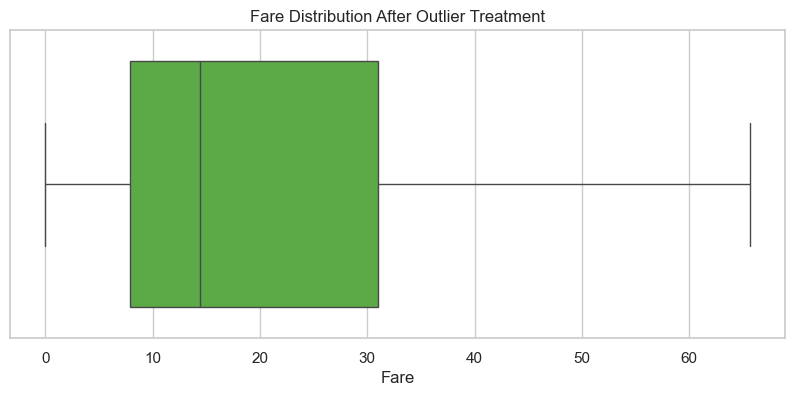

In [33]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_clean["Fare"], color="#51B937")  # Create a boxplot for the 'Fare' column after capping
plt.title("Fare Distribution After Outlier Treatment")  # Set the title of the plot
plt.xlabel("Fare")  # Set the x-axis label
plt.savefig("../report/fare_boxplot_after.png", dpi=300, bbox_inches="tight")  # Save the plot as a PNG file
plt.show()  # Display the plot


## Final Dataset Validation

After preprocessing, the dataset was checked again for missing values, duplicate records, data types, and final dimensions. This validation ensures that the cleaned dataset is ready for future exploratory analysis and machine-learning tasks.

In [34]:
df_clean = df_clean.drop(columns=["Fare_Before_Capping"])  # Drop the 'Fare_Before_Capping' column as it is no longer needed
print("Temporary comparison column removed")
print("Columns in final dataset: ")
print(df_clean.columns.tolist())  # Print the final list of columns in the cleaned DataFrame


Temporary comparison column removed
Columns in final dataset: 
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']


In [36]:
print("Final dataset shape:", df_clean.shape)  # Print the shape of the final cleaned DataFrame
print("Total missing values: ", df_clean.isna().sum().sum())  # Print the total number of missing values in the cleaned DataFrame
print("Duplicate rows: ", df_clean.duplicated().sum())  # Print the number of duplicate rows in the cleaned DataFrame
print("Missing values by column: ")
print(df_clean.isna().sum())  # Print the number of missing values for each column in the cleaned DataFrame
print("Final data type: ")
print(df_clean.dtypes)  # Print the data types of the final cleaned DataFrame


Final dataset shape: (891, 11)
Total missing values:  0
Duplicate rows:  0
Missing values by column: 
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64
Final data type: 
PassengerId       int64
Survived       category
Pclass         category
Name             object
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Embarked       category
dtype: object


In [37]:
df_clean[["Age", "Fare", "SibSp", "Parch"]].describe()  # Display summary statistics for numerical columns in the cleaned DataFrame


,Age,Fare,SibSp,Parch
count,891.000000,891.000000,891.000000,891.000000
mean,29.066409,24.046813,0.523008,0.381594
std,13.244532,20.481625,1.102743,0.806057
min,0.420000,0.000000,0.000000,0.000000
25%,22.000000,7.910400,0.000000,0.000000
50%,26.000000,14.454200,0.000000,0.000000
75%,37.000000,31.000000,1.000000,0.000000
max,80.000000,65.634400,8.000000,6.000000


In [38]:
output_path = "../data/cleaned_data.csv"  # Define the output path for the cleaned dataset
df_clean.to_csv(output_path, index=False)  # Save the cleaned DataFrame to a CSV file
print(f"Cleaned dataset saved to {output_path}")  # Print a message indicating where the cleaned dataset has been saved


Cleaned dataset saved to ../data/cleaned_data.csv


In [39]:
df_saved = pd.read_csv("../data/cleaned_data.csv")  # Load the cleaned dataset from the CSV file
print("Reloaded dataset shape: ", df_saved.shape)  # Print the shape of the reloaded cleaned DataFrame
print("Total missing values in reloaded dataset: ", df_saved.isna().sum().sum())  # Print the total number of missing values in the reloaded cleaned DataFrame
df_saved.head()  # Display the first few rows of the reloaded cleaned DataFrame


Reloaded dataset shape:  (891, 11)
Total missing values in reloaded dataset:  0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,65.6344,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


## Conclusion

The Titanic dataset was successfully cleaned and preprocessed for future analysis. The `Cabin` column was removed because it contained 77.10% missing values. Missing values in `Embarked` were filled using the mode, while missing Age values were imputed using the median age within each passenger class. No fully duplicated rows were found.

Potential Fare outliers were identified using the IQR method. Instead of deleting passenger records, extreme Fare values were capped at the upper IQR bound to reduce their influence while preserving all observations. The final dataset contains 891 rows and 11 columns, with no missing values and no duplicate records. It was exported as `cleaned_data.csv` and is ready for exploratory data analysis and machine-learning applications.